# Part 2 — CML attenuation vs precipitation phase

Loads `dataset/raw/full/outputs/cml_attenuation_baselines.nc` (built by
`methods/cml_baseline.py`) and analyses baseline-reduced CML attenuation against the
`wu_airport`+`temp_guard` precipitation-phase index, for NYC Mesh links **> 900 m**.

All heavy logic lives in `methods/cml_analysis.py` and `nycmesh_utils.plot_cml_phase_scatter`;
cells here are just knobs + one call. Phase colours match the rest of the project
(rain `#2166ac`, mixed `#e377c2`, snow `#00e5ff`).

Sections: **2.1** phase scatter · **2.2** CDF by band · **2.3** temperature effect ·
**2.4** ITU-R P.838 rain-rate retrieval · **2.5** multi-band same-CML ·
**2.6** per-link baseline diagnostic.

In [2]:
# --- setup + knobs -------------------------------------------------------
# autoreload picks up edits to cml_analysis.py without a kernel restart
%load_ext autoreload
%autoreload 2
import sys, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, '../src'); sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import cml_analysis as A
from analysis.nycmesh_utils import plot_cml_phase_scatter

ATT_VAR    = 'att_rollq'   # baseline method: att_static | att_rollq | att_drymed | att_ewma
BAND_FOCUS = 'V-high'     # band for single-band sections (2.3, 2.4): the >65 GHz priority
MIXED_MODE = 'separate'   # 2.2 mixed handling: 'separate' | 'drop' | 'fold_rain'
MIN_PRECIP = 0.1          # mm/h floor for the ITU rate comparison (2.4)

# Single 10-min fine base; every cell resamples from it via RES (sample-accordingly).
BASE_NC = A.BASE10_NC if A.BASE10_NC.exists() else A.OUT_NC   # 10-min base once built, else 1h
RES     = '30min'        # analysis cadence resampled from BASE_NC: '10min' | '30min' | '1h' | '3h'
df = A.load_attenuation_long(nc_path=BASE_NC, att_var=ATT_VAR, keep='wet',
                             impute_failures=True, freq=RES)
print(f'base={BASE_NC.name}  RES={RES}')
print(f'{len(df):,} wet sublink-bins  |  bands: {df.band_tier.value_counts().to_dict()}')
print(f'phases: {df.phase.value_counts().to_dict()}  |  failure-imputed rows: {int(df.failure.sum()):,}')

base=cml_attenuation_baselines_10min.nc  RES=30min
816,115 wet sublink-bins  |  bands: {'sub6': 527208, 'V-high': 213028, 'V-low': 42717, 'K': 33162}
phases: {'rain': 586496, 'snow': 210575, 'mixed': 19044}  |  failure-imputed rows: 214,913


## 2.0 — Link map
Interactive map of the NYC Mesh CML links used here (one line per parent link,
coloured by band; click a line for cml_id / bands / length). Set `MAP_LINKS` to the
same selection you pass as `cmls` / `LINKS` in the CDF cells to see exactly which
links it covers — selected links are highlighted, the rest dimmed grey.

In [3]:
# Map of CML links — see which links you're selecting (matches the LINKS / cmls knob).
MAP_LINKS       = None    # None = all 119 links | A.multiband_cml_ids(df) → 16/207/22 | ['16','207']
MAP_SEPARATE_VB = True    # False = colour V-low+V-high as one 'V'
A.plot_links_map(cmls=MAP_LINKS, separate_vbands=MAP_SEPARATE_VB)   # interactive Folium map

## 2.1 — Multi-panel phase scatter: specific attenuation vs precip rate
One panel per band tier. Specific attenuation (dB/km) on y, hourly precip on x (log).
Mid-event link outages are imputed to the event-max attenuation and marked with open
**X** crosses so they stay visible.

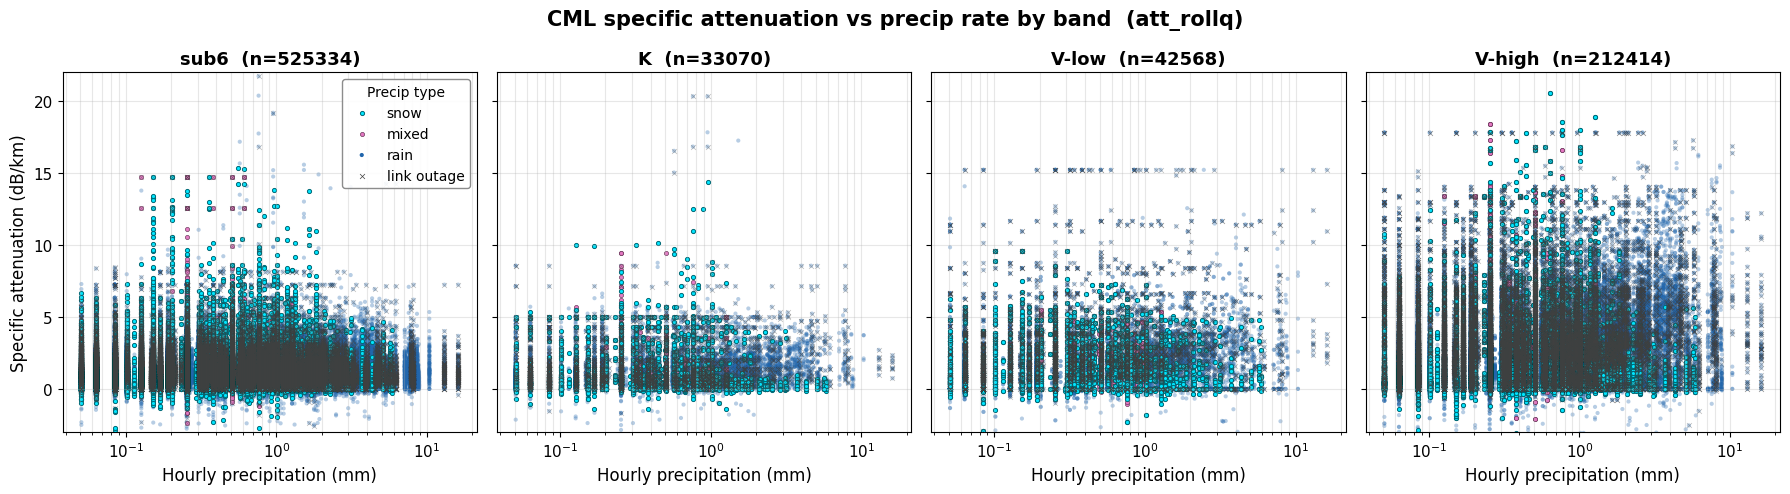

In [4]:
_ = plot_cml_phase_scatter(
    df, facet='band_tier', x='precip_mm', y='att_per_km',
    xscale='log', yscale='linear', ylim=(-3, 22), figsize=(18, 5), point_size=9,
    suptitle=f'CML specif'
             f'ic attenuation vs precip rate by band  ({ATT_VAR})')
plt.show()

## 2.2 — CDF of specific attenuation per band, conditioned on phase
Rain vs snow (and mixed per `MIXED_MODE`). A right-shifted rain CDF relative to snow
is the dry-snow-transparency signature; the gap should widen with frequency.

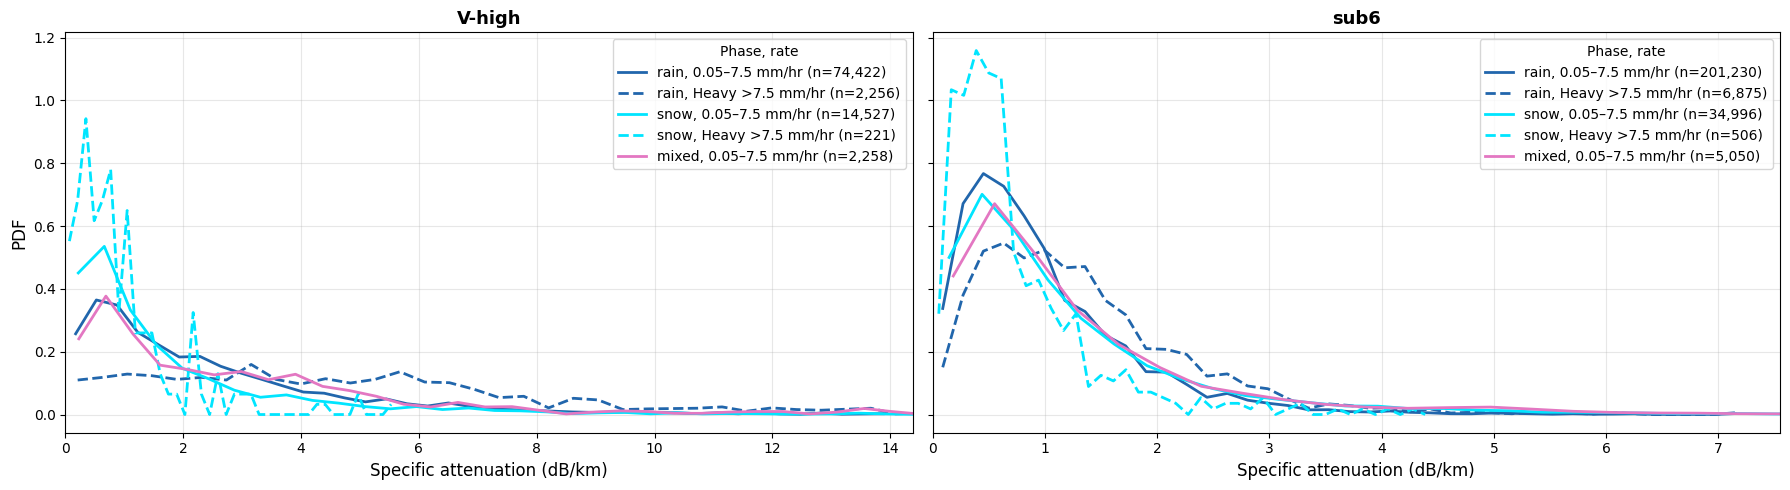

In [16]:
# plot knobs ▸ which phases / bands, temperature split, and CDF range
PHASES    = ['rain', 'snow', 'mixed' ]     # None = all | e.g. ['snow'] | ['rain','snow']
BANDS     = ['V-high','sub6'] # A.BAND_ORDER         # all bands | e.g. ['V-high','sub6'] to focus
SEPARATE_VBANDS = True   # True = V-low & V-high separate | False = merge into one 'V' band
PCPN_INTENSE = 'all'   # rain-rate window: 'all' | 'light' (0.1-2.5) | 'moderate' (2.5-7.5) | 'heavy' (>7.5) mm/hr
PCPN_SPLIT   =   [0.05, 7.5 , np.inf]    # None | [0.1, 2.5, 7.5, np.inf] = overlay Light/Moderate/Heavy as curves (line style; takes the split slot over TEMP)
TEMP_BINS    = None                 # None = phase only | [-np.inf, -1, np.inf] = below / at-or-above -1°C
CDF_VALUE    = 'att_per_km'         # 'att_per_km' | 'att'
MIN_ATT      = 0.0                  # lower cutoff; -np.inf includes ≤0 (full distribution)
XCLIP_PCT    = 99.9              # right x-limit pct; 100 shows the full tail to CDF=1.0
TEMP_COL     = 'temp_wb_c'   # temp axis: 'temp_c' = air | 'temp_wb_c' = wet-bulb (Stull; ASOS dewpoint + WU RH backfill)
if TEMP_COL == 'temp_wb_c' and 'temp_wb_c' not in df.columns:
    df = A.add_wet_bulb(df)   # one-time: ASOS+WU wet-bulb -> df['temp_wb_c']
KIND = 'pdf'   # 'cdf' | 'pdf' (probability-density line)
_ = A.plot_cdf_by_phase_band(df, kind=KIND, precip_bins=PCPN_SPLIT, precip_range=PCPN_INTENSE, separate_vbands=SEPARATE_VBANDS, temp_col=TEMP_COL, bands=BANDS, phases=PHASES, mixed=MIXED_MODE,
                             value=CDF_VALUE, temp_bins=TEMP_BINS,
                             min_att=MIN_ATT, xclip_pct=XCLIP_PCT, figsize=(18, 5))
plt.show()

## 2.2b — CDF per precip type, bands overlaid
Transpose of 2.2: one panel **per precipitation type** with one CDF **per band**
(colour low→high frequency), so the frequency dependence of attenuation is read
*within* a fixed phase. In rain the high bands shift right (more attenuation); in
snow the bands bunch together (weak frequency dependence — dry-snow transparency).
Same knobs as 2.2 (`phases`, `bands`, `temp_bins`, `min_att`, `xclip_pct`).

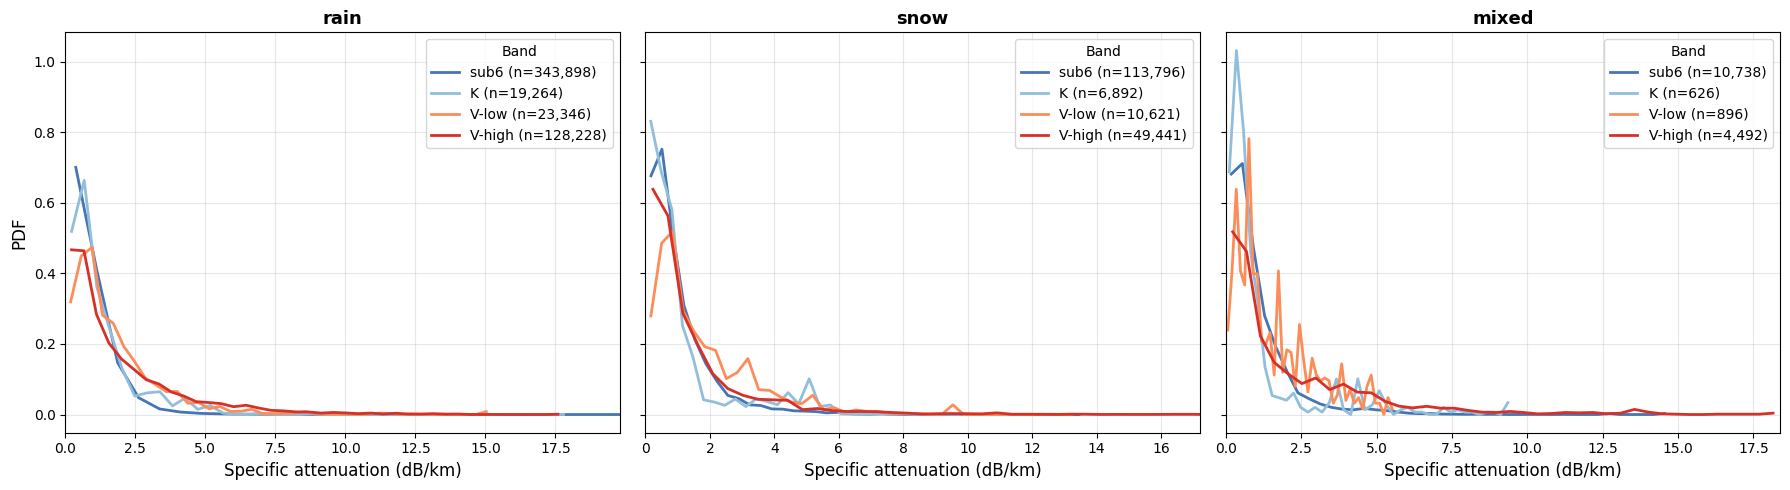

In [15]:
# plot knobs ▸ panels = precip type, lines = band; choose links + optional temp split
PHASE_PANELS = ('rain', 'snow' , 'mixed')            # which precip types get a panel | e.g. ['snow']
FACET_BY     = 'phase'   # panels split by: 'phase' (rain/snow/...) | 'precip' (Light/Moderate/Heavy; uses PCPN_SPLIT edges)
BAND_LINES   =  A.BAND_ORDER #['V-high', 'sub6' ,'k']          # bands overlaid per panel | A.BAND_ORDER for all
SEPARATE_VBANDS = True   # True = V-low & V-high separate | False = merge into one 'V' band
PCPN_INTENSE = 'all'   # rain-rate window: 'all' | 'light' (0.1-2.5) | 'moderate' (2.5-7.5) | 'heavy' (>7.5) mm/hr
PCPN_SPLIT   = None   # None | [0.1, 2.5, 7.5, np.inf] = overlay Light/Moderate/Heavy as curves (line style; takes the split slot over TEMP)
LINKS        =None   #A.multiband_cml_ids(df)    #A.multiband_cml_ids(df) #None                        # None = all | ['16'] | A.multiband_cml_ids(df) → 16/207/22
TEMP_SPLIT   = None #[-np.inf, -2, np.inf]       # None | [-np.inf, 0, np.inf] (line style per temp bin)
MIN_ATT_B    = 0.0                         # -np.inf to include ≤0 (full distribution)
XCLIP_B      = 99.99                   # 100 shows the full tail to CDF=1.0
TEMP_COL = 'temp_wb_c'  # temp axis: 'temp_c' = air | 'temp_wb_c' = wet-bulb (Stull; ASOS dewpoint + WU RH backfill)
if TEMP_COL == 'temp_wb_c' and 'temp_wb_c' not in df.columns:
    df = A.add_wet_bulb(df)   # one-time: ASOS+WU wet-bulb -> df['temp_wb_c']
KIND = 'pdf'   # 'cdf' | 'pdf' (probability-density line)
_ = A.plot_cdf_band_by_phase(df, kind=KIND, facet_by=FACET_BY, precip_bins=PCPN_SPLIT, precip_range=PCPN_INTENSE, separate_vbands=SEPARATE_VBANDS, temp_col=TEMP_COL, phases=PHASE_PANELS, bands=BAND_LINES, cmls=LINKS,
                             temp_bins=TEMP_SPLIT, min_att=MIN_ATT_B,
                             xclip_pct=XCLIP_B, figsize=(18, 5))
plt.show()

## 2.2c — Temperature-threshold sweep
For a fixed band, sweep a set of temperature cuts and overlay the CDF on one side
of each (colour cold→warm), one panel per phase. **Rain** CDFs collapse together
(temperature-insensitive); **snow** CDFs fan out, locating the temperature where
snow attenuation changes. `side='below'` → temp < T, `'above'` → temp ≥ T.

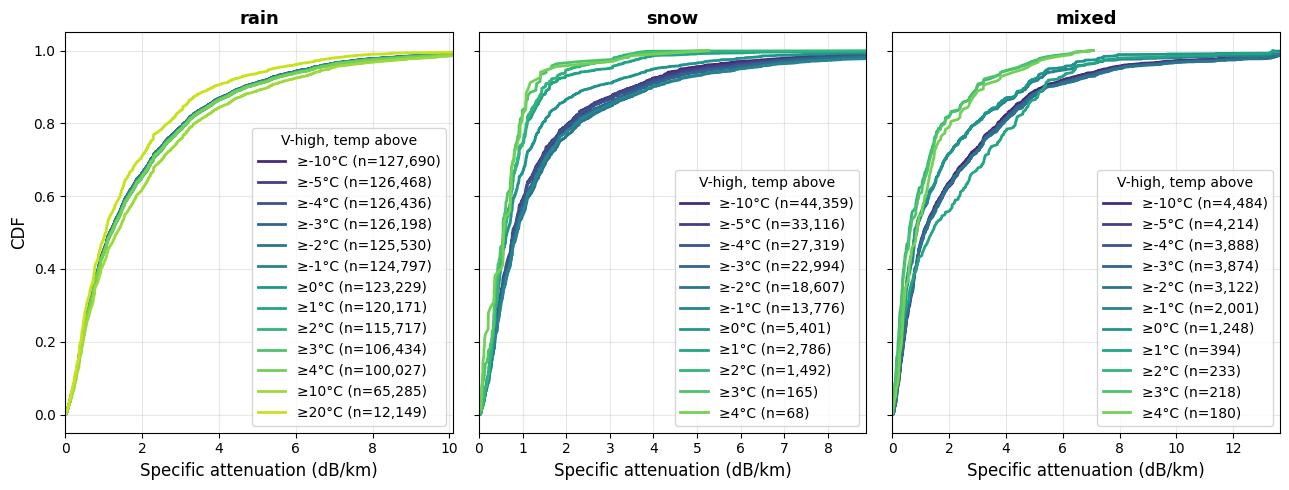

In [7]:
# plot knobs ▸ sweep a temperature cut, overlay the CDF for each split (colour cold→warm)
SWEEP_PHASES = ('rain', 'snow', 'mixed')        # one panel per phase
SWEEP_BAND   = 'V-high'                # single band (specific attenuation is band-dependent)
THRESHOLDS   = [ -10, -5,-4, -3 ,-2,-1, 0, 1 , 2 , 3, 4, 10, 20]       # temperature cuts (°C) to sweep
SIDE         = 'above'                 # 'above' = temp ≥ T | 'below' = temp < T
SWEEP_LINKS  = None                    # None = all | ['16'] | A.multiband_cml_ids(df)
TEMP_COL = 'temp_wb_c'    # temp axis: 'temp_c' = air | 'temp_wb_c' = wet-bulb (Stull; ASOS dewpoint + WU RH backfill)
if TEMP_COL == 'temp_wb_c' and 'temp_wb_c' not in df.columns:
    df = A.add_wet_bulb(df)   # one-time: ASOS+WU wet-bulb -> df['temp_wb_c']
KIND = 'cdf'   # 'cdf' | 'pdf' (probability-density line)
_ = A.plot_cdf_temp_sweep(df, kind=KIND, temp_col=TEMP_COL, phases=SWEEP_PHASES, band=SWEEP_BAND,
                          thresholds=THRESHOLDS, side=SIDE, cmls=SWEEP_LINKS,
                          xclip_pct=99, figsize=(13, 5))
plt.show()

## 2.2d — Dry vs wet snow: disjoint temperature bins
`side='bins'` turns the thresholds into **disjoint** [lo, hi) intervals (not the
nested ≥T sweep in 2.2c), so each CDF is an independent slice. With wet-bulb edges
`[-inf, -2, 1, inf]` this separates **dry** (<-2°C), **transition/melting** (-2…1°C)
and **wet** (≥1°C) snow — the melting band attenuates V-band most (wet-snow effect).

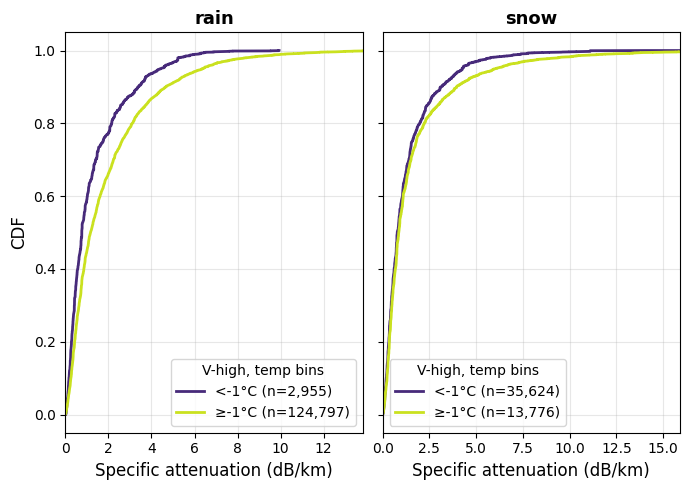

In [8]:
# plot knobs ▸ DISJOINT temperature bins (dry / transition / wet) — thresholds are bin EDGES
BIN_PHASES = ('rain' ,
              'snow',)                  # one panel per phase | e.g. ('rain','snow')
BIN_BAND   = 'V-high'                   # single band (attenuation is band-dependent)
BIN_EDGES  = [-np.inf,-1, np.inf]   # edges → bins: <-2 (dry) | -2…1 (melting) | ≥1 (wet)
BIN_COLORS = None   # None = viridis | e.g. ['#1b9e77','#d95f02','#7570b3','#e7298a'] (one per bin, cold→warm)
BIN_LINKS  = None                       # None = all | ['16'] | A.multiband_cml_ids(df)
PCPN_INTENSE = 'all'   # SEPARATE figs by rain rate: 'all' | 'light' | 'moderate' | 'heavy' (re-run per value)
TEMP_COL   = 'temp_wb_c'                # 'temp_c' = air | 'temp_wb_c' = wet-bulb (recommended)
if TEMP_COL == 'temp_wb_c' and 'temp_wb_c' not in df.columns:
    df = A.add_wet_bulb(df)
KIND = 'cdf'   # 'cdf' | 'pdf' (probability-density line)
_ = A.plot_cdf_temp_sweep(df, colors=BIN_COLORS, precip_range=PCPN_INTENSE, kind=KIND, phases=BIN_PHASES, band=BIN_BAND, thresholds=BIN_EDGES,
                          side='bins', cmls=BIN_LINKS, temp_col=TEMP_COL,
                          xclip_pct=99.9, figsize=(7, 5))
plt.show()

## 2.3 — Temperature effect
2-D scatter of specific attenuation vs ASOS temperature, coloured by phase, for the
focus band. Shows the cold-snow / warm-rain separation around 0 °C and where snow
attenuation sits relative to rain at a given temperature.

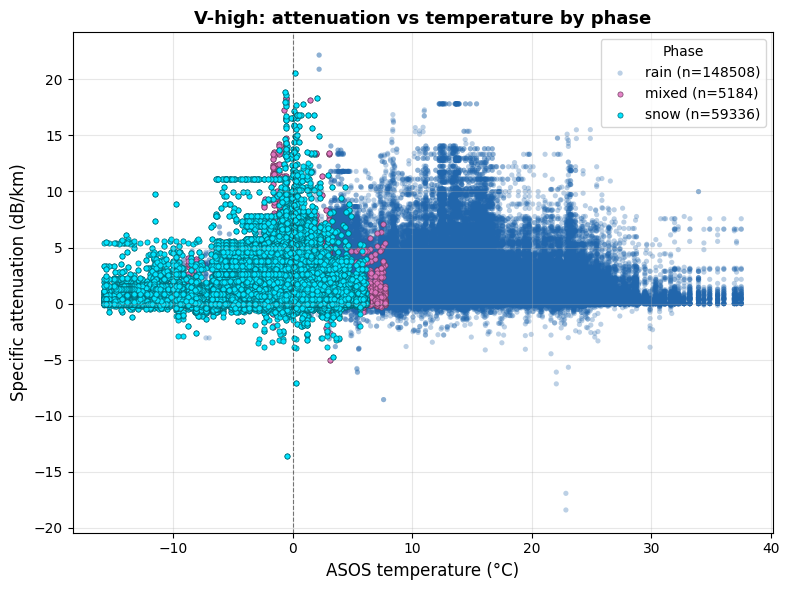

In [9]:
_ = A.plot_temp_effect(df, band=BAND_FOCUS, figsize=(8, 6), point_size=14)
plt.show()

## 2.4 — Rain-rate retrieval (ITU-R P.838) vs ASOS
Invert `A = k·R^α·L` per link with frequency/polarisation-appropriate k, α
(`methods/cml_rainrate.py`). Scatter CML-retrieved rain rate vs ASOS rate coloured
by phase — snow/mixed points expose where the rain-only retrieval fails — and a
per-link skill table (bias / RMSE / R² / Pearson r).

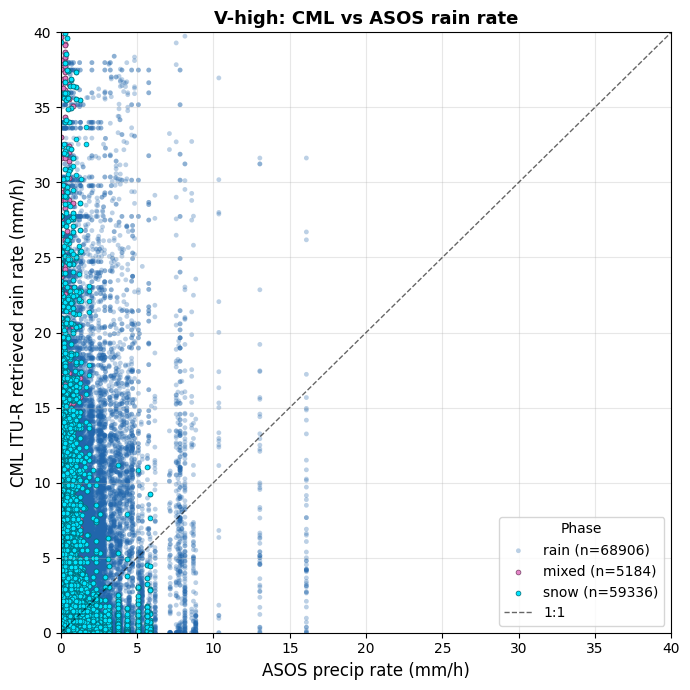

88 V-high links | median  r=0.31  R2=-9.01  bias=+1.96  rmse=3.78 mm/h


,sublink,freq_GHz,length_km,n_hours,bias_mmh,rmse_mmh,R2,pearson_r,med_cml_R,med_asos
0,129::sublink_7,67.000000,3.49,991,1.25,2.18,-1.305,0.620,1.44,0.44
1,77::sublink_1,69.099998,1.88,135,1.78,2.45,-6.953,0.618,1.88,0.44
2,77::sublink_2,69.099998,1.88,135,1.78,2.45,-6.953,0.618,1.88,0.44
3,129::sublink_5,67.000000,3.49,991,1.45,2.47,-1.961,0.557,1.46,0.44
4,131::sublink_1,67.000000,2.79,1509,1.74,2.89,-3.850,0.551,1.69,0.44
5,131::sublink_3,67.000000,2.79,1509,1.80,2.92,-3.941,0.549,1.69,0.44
6,216::sublink_2,68.000000,2.96,303,1.96,3.54,-18.363,0.502,1.19,0.44
7,216::sublink_1,68.000000,2.96,303,1.96,3.54,-18.363,0.502,1.19,0.44
8,217::sublink_2,65.900002,2.19,1526,3.28,5.26,-15.084,0.496,2.67,0.44
9,217::sublink_1,65.900002,2.19,1526,3.35,5.35,-15.640,0.495,2.48,0.44


In [10]:
_ = A.plot_itu_scatter(df, band=BAND_FOCUS, color_by_phase=True,
                       min_precip_mm=MIN_PRECIP, max_rate=40, figsize=(7, 7))
plt.show()

tab = A.itu_rainrate_table(df, band=BAND_FOCUS, phase='rain', min_precip_mm=MIN_PRECIP)
print(f'{len(tab)} {BAND_FOCUS} links | median  r={tab.pearson_r.median():.2f}  '
      f'R2={tab.R2.median():.2f}  bias={tab.bias_mmh.median():+.2f}  '
      f'rmse={tab.rmse_mmh.median():.2f} mm/h')
tab.head(10)

**Reading 2.4:** V-band retrieval has real correlation (top links r ≈ 0.65–0.70) but
poor per-hour absolute accuracy (R² ≤ 0) — path-integrated CML vs point ASOS, plus
V-band saturation in heavy rain and wet-antenna effects. Tightening `MIN_PRECIP`
lowers correlation (range restriction + saturation) while pulling bias toward 0.

## 2.5 — Multi-band, same physical path
CMLs whose sublinks span more than one band (Δf > 1 GHz). For such a link the
**same path** is observed at very different frequencies, isolating the frequency
dependence of rain/snow attenuation from path geometry.

In [11]:
mb = A.find_multiband_cmls(min_df_ghz=1.0)
print(f'{len(mb)} multi-band CMLs (Δf > 1 GHz):')
display(mb)

CML = mb.iloc[0]['cml_id']   # widest frequency spread
print(f'\nPer-band specific attenuation by phase for CML {CML}:')
A.multiband_phase_stats(df, CML)

3 multi-band CMLs (Δf > 1 GHz):


,cml_id,n_sublinks,bands,freqs_GHz,df_GHz,length_km
0,16,8,V-high/sub6,5.5/5.6/69.1,63.599998,3.30
1,207,4,V-high/sub6,5.5/67.0,61.500000,1.80
2,22,4,K/sub6,5.5/24.2,18.700001,1.48



Per-band specific attenuation by phase for CML 16:


,sublink,freq_GHz,phase,mean,median,count
0,16::sublink_1,5.520000,mixed,0.485,0.556,68
1,16::sublink_2,5.520000,mixed,0.177,0.152,68
2,16::sublink_1,5.520000,rain,0.451,0.455,1120
3,16::sublink_2,5.520000,rain,0.283,0.253,1120
4,16::sublink_1,5.520000,snow,0.518,0.506,784
5,16::sublink_2,5.520000,snow,0.228,0.152,784
6,16::sublink_5,5.560000,mixed,0.599,0.708,90
7,16::sublink_6,5.560000,mixed,0.238,0.202,90
8,16::sublink_7,5.560000,mixed,0.755,0.657,90
9,16::sublink_8,5.560000,mixed,0.616,0.367,90


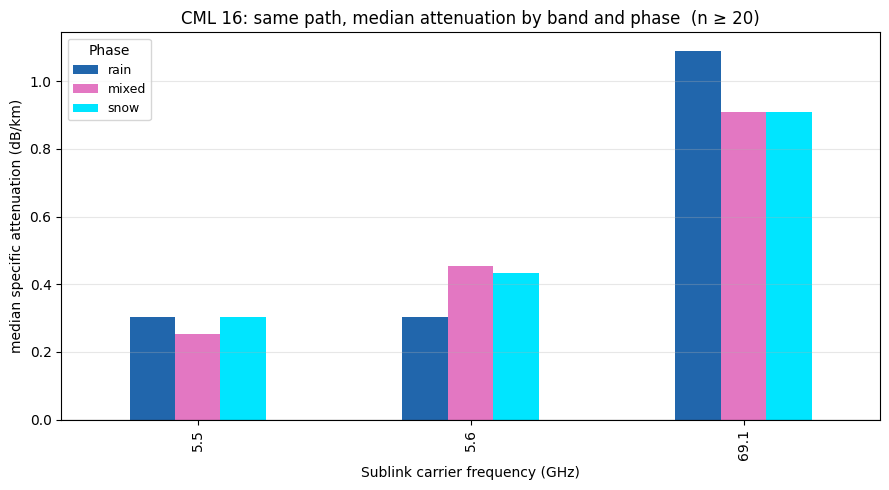

In [12]:
# Same-path frequency comparison for the chosen CML.
# plot knobs ▸ how to summarise each band:
STAT        = 'median'   # 'median' (typical hour) | 'mean' | 'p90' (wet tail — recommended)
PER_SUBLINK = False      # False = pool by frequency | True = one bar per sublink (shows spread)
MIN_COUNT   = 20         # drop band×phase cells with fewer than this many hours
_ = A.plot_multiband_bars(df, CML, stat=STAT, per_sublink=PER_SUBLINK, min_count=MIN_COUNT)
plt.show()

## 2.6 — Per-link baseline diagnostic (RSL · baselines · ASOS context)
For one sublink: hourly **RSL** with the chosen **baseline(s)** overlaid (top), the
resulting **attenuation = baseline − RSL** with a 0-line (middle), and **ASOS network
precip + temperature** (bottom); wet hours shaded by phase. Contrasts the unbiased
`ewma` baseline against the high-quantile `rollq`, which rides ~0.6 dB above the true
dry level — so `rollq` rarely goes negative, but only because of that bias. Default
window = this link's largest precip event.

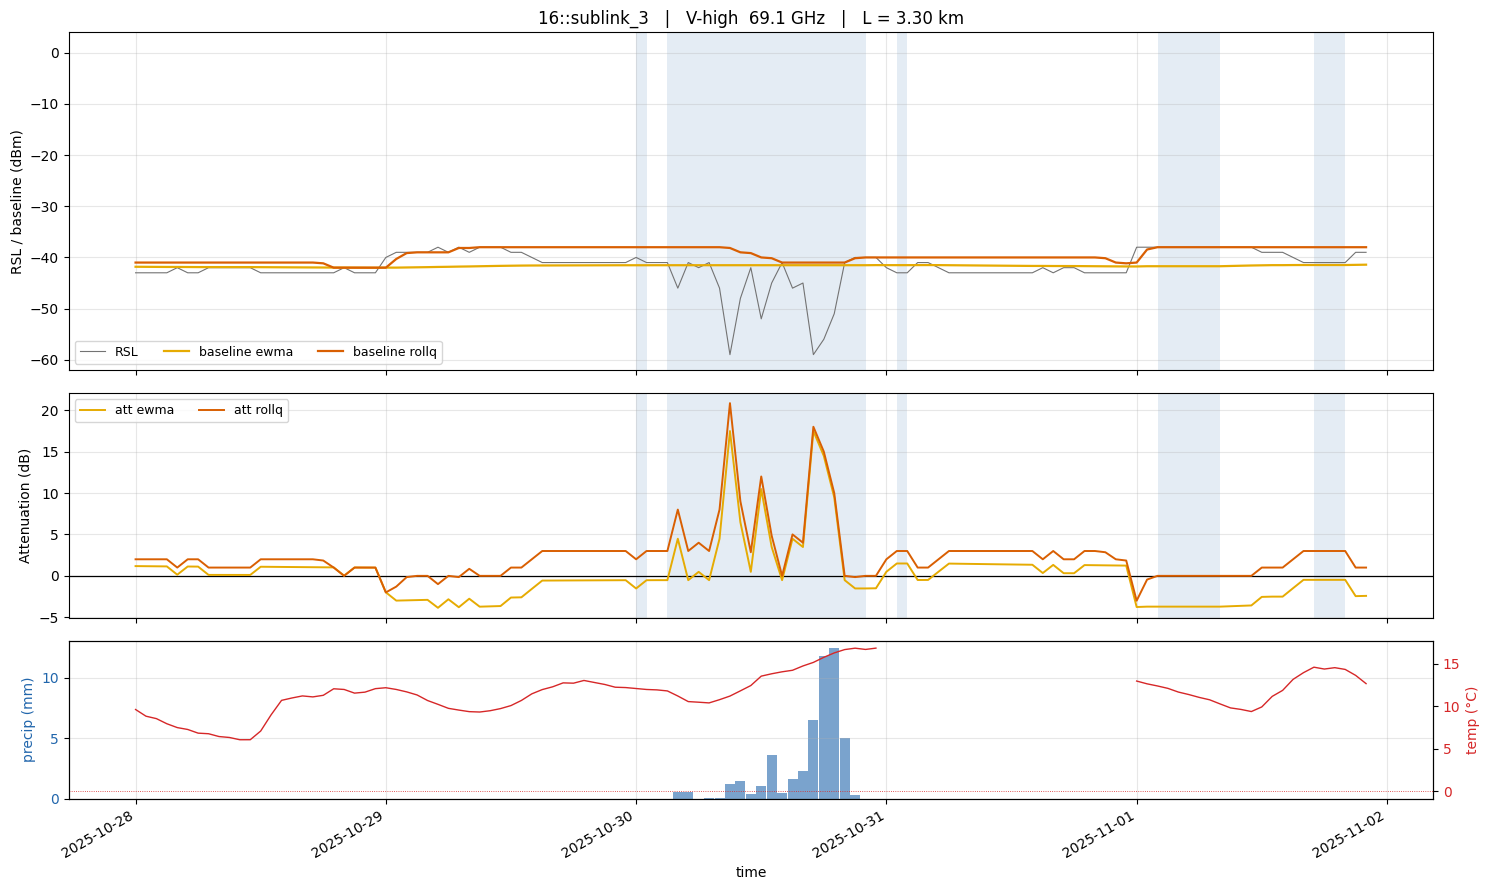

In [13]:
# Knobs: sublink key, baselines to overlay, optional window=('YYYY-MM-DD','YYYY-MM-DD').
LINK_OK = '16::sublink_3'      # V-high 69 GHz: ~20 dB attenuation through the rain event
_ = A.plot_link_baselines(LINK_OK, methods=['ewma', 'rollq'])

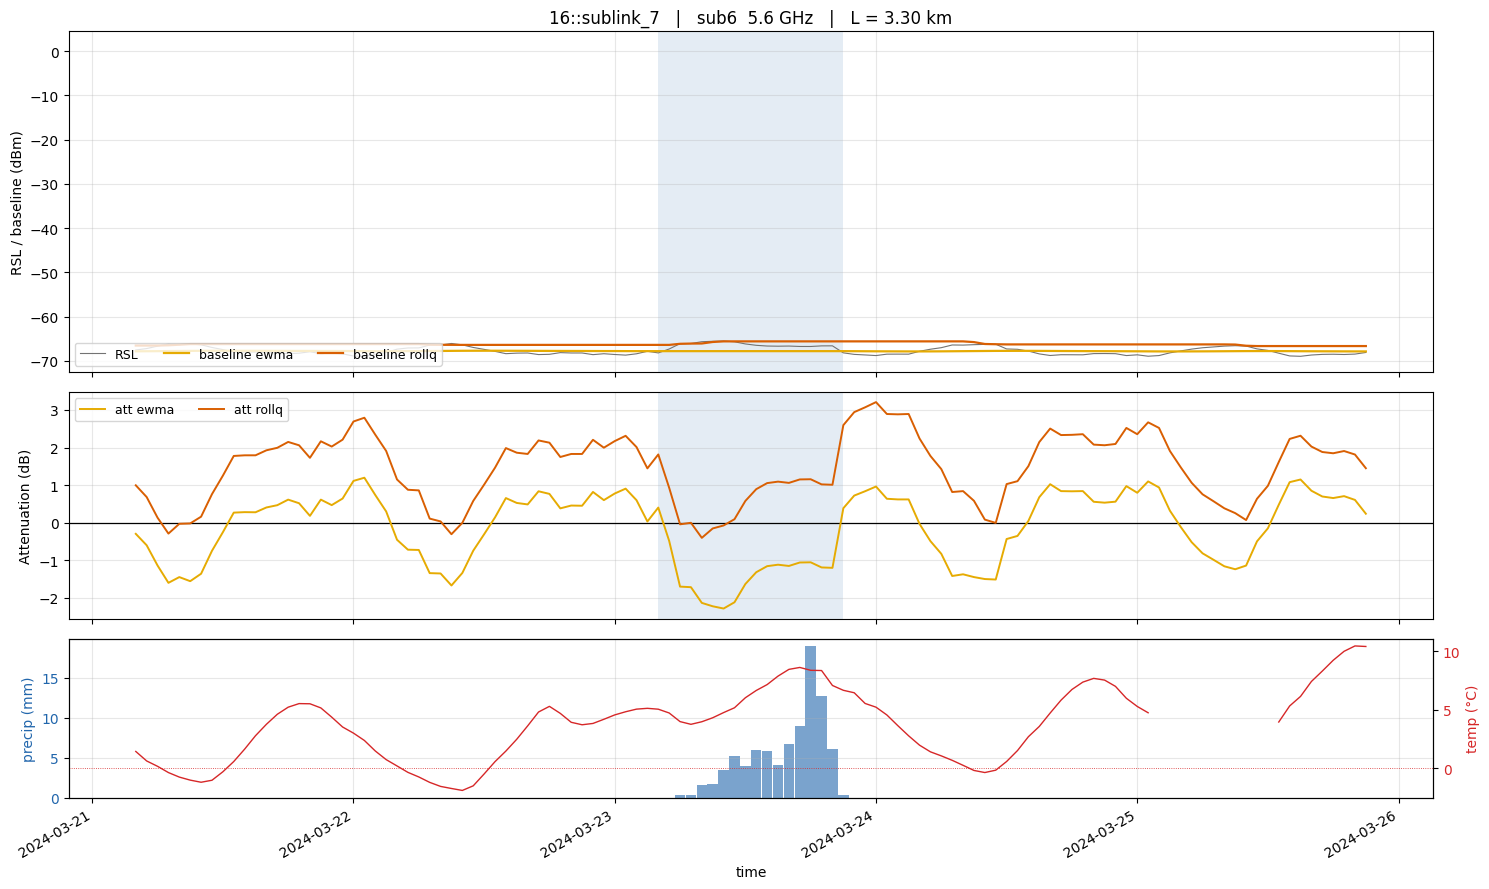

In [14]:
# Same view on a biased sub6 sublink: attenuation dips NEGATIVE through the rain
# event (RSL rises during rain — unphysical), a per-link QC flag, not real signal.
LINK_BAD = '16::sublink_7'
_ = A.plot_link_baselines(LINK_BAD, methods=['ewma', 'rollq'])